In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import fastparquet

In [2]:
df_par = pd.read_parquet("swiftride_10M.parquet", engine="fastparquet")
df_par.head()

,trip_id,rider_id,driver_id,trip_start_time,trip_end_time,trip_distance,trip_duration,fare_amount,surge_multiplier,driver_rating,rider_rating,payment_method,traffic_condition,weather,day_of_week,hour_of_day,driver_tenure_days,rider_tenure_days
0,T000001,R00770,D02434,2025-03-22 07:40:22,2025-03-22 07:44:21.400,1.7,239.4,5.40,2.0,4.2,4.8,Wallet,Heavy,Clear,5,7,37,19
1,T000002,R11395,D03557,2025-01-16 06:05:51,2025-01-16 06:08:51.000,0.6,180.0,3.20,2.0,4.1,4.6,Cash,Heavy,Rain,3,6,87,58
2,T000003,R48556,D17160,2025-01-13 04:53:06,2025-01-13 05:03:16.000,4.8,610.0,9.20,1.0,4.5,4.6,Wallet,Moderate,Clear,0,4,24,34
3,T000004,R37066,D00996,2025-03-07 00:24:14,2025-03-07 00:29:56.000,3.1,342.0,7.58,1.6,4.4,4.9,Card,Light,Clear,4,0,3,222
4,T000005,R39100,D08572,2024-10-14 02:46:37,2024-10-14 03:03:19.000,7.0,1002.0,15.30,1.8,4.4,4.5,Cash,Moderate,Clear,0,2,70,107


In [3]:
print(f"The data set shapes is {df_par.shape} \n and the columns are {df_par.columns}")

The data set shapes is (10000000, 18) 
 and the columns are Index(['trip_id', 'rider_id', 'driver_id', 'trip_start_time', 'trip_end_time',
       'trip_distance', 'trip_duration', 'fare_amount', 'surge_multiplier',
       'driver_rating', 'rider_rating', 'payment_method', 'traffic_condition',
       'weather', 'day_of_week', 'hour_of_day', 'driver_tenure_days',
       'rider_tenure_days'],
      dtype='str')


In [4]:
df_par.describe().T

,count,mean,min,25%,50%,75%,max,std
trip_start_time,10000000,2024-12-30 23:54:13.323719,2024-10-02 00:00:00,2024-11-16 00:49:55.500000,2024-12-30 23:46:37.500000,2025-02-13 23:26:08,2025-03-30 23:59:58,NaN
trip_end_time,10000000,2024-12-31 00:11:40.179727,2024-10-02 00:03:26,2024-11-16 01:06:23.750000,2024-12-31 00:02:48.300000,2025-02-13 23:42:36.700000,2025-03-31 01:39:17,NaN
trip_distance,10000000.0,6.170387,0.1,2.6,4.5,7.7,297.8,5.847609
trip_duration,10000000.0,1046.856011,180.0,417.6,736.0,1300.0,7200.0,1000.61072
fare_amount,10000000.0,13.147487,2.15,6.68,10.05,15.86,523.15,10.668501
surge_multiplier,10000000.0,1.613286,1.0,1.4,1.6,1.8,3.0,0.352335
driver_rating,10000000.0,4.375887,2.6,4.2,4.4,4.6,5.0,0.316962
rider_rating,10000000.0,4.596815,3.5,4.5,4.6,4.7,5.0,0.195626
day_of_week,10000000.0,3.026588,0.0,1.0,3.0,5.0,6.0,1.992746
hour_of_day,10000000.0,11.50194,0.0,6.0,12.0,18.0,23.0,6.92164


In [5]:
print(df_par.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000000 entries, 0 to 9999999
Data columns (total 18 columns):
 #   Column              Dtype         
---  ------              -----         
 0   trip_id             object        
 1   rider_id            object        
 2   driver_id           object        
 3   trip_start_time     datetime64[us]
 4   trip_end_time       datetime64[us]
 5   trip_distance       float64       
 6   trip_duration       float64       
 7   fare_amount         float64       
 8   surge_multiplier    float64       
 9   driver_rating       float64       
 10  rider_rating        float64       
 11  payment_method      object        
 12  traffic_condition   object        
 13  weather             object        
 14  day_of_week         int64         
 15  hour_of_day         int64         
 16  driver_tenure_days  int64         
 17  rider_tenure_days   int64         
dtypes: datetime64[us](2), float64(6), int64(4), object(6)
memory usage: 1.3+ GB
None


In [6]:
df_par.isnull().sum()

trip_id               0
rider_id              0
driver_id             0
trip_start_time       0
trip_end_time         0
trip_distance         0
trip_duration         0
fare_amount           0
surge_multiplier      0
driver_rating         0
rider_rating          0
payment_method        0
traffic_condition     0
weather               0
day_of_week           0
hour_of_day           0
driver_tenure_days    0
rider_tenure_days     0
dtype: int64

In [7]:
df_par.nunique()

trip_id               10000000
rider_id                 49999
driver_id                19999
trip_start_time        7376435
trip_end_time          8675592
trip_distance             1326
trip_duration            18724
fare_amount               9273
surge_multiplier            21
driver_rating               25
rider_rating                16
payment_method               3
traffic_condition            3
weather                      4
day_of_week                  7
hour_of_day                 24
driver_tenure_days        1109
rider_tenure_days         1422
dtype: int64

### Missing Values Handling

there are no missing values, no cleaning is required.

In [8]:
numerical_cols = df_par.select_dtypes(include=np.number).columns
print(f"numerical_cols are {numerical_cols.__len__()}")
print(numerical_cols)


numerical_cols are 10
Index(['trip_distance', 'trip_duration', 'fare_amount', 'surge_multiplier',
       'driver_rating', 'rider_rating', 'day_of_week', 'hour_of_day',
       'driver_tenure_days', 'rider_tenure_days'],
      dtype='str')


In [9]:
categorical_cols = df_par.select_dtypes(include="object").columns
print(f"categorical_cols are {categorical_cols.__len__()}")
print(categorical_cols)

categorical_cols are 6
Index(['trip_id', 'rider_id', 'driver_id', 'payment_method',
       'traffic_condition', 'weather'],
      dtype='str')


## Variable Classification

| Column | Pandas Detected Type | Statistical Type | Subtype | Justification |
|---|---|---|---|---|
| trip_id | Categorical/Object | Categorical | Nominal | Unique trip identifier; no mathematical meaning or order |
| rider_id | Categorical/Object | Categorical | Nominal | Anonymized rider identifier; no natural order |
| driver_id | Categorical/Object | Categorical | Nominal | Anonymized driver identifier; no natural order |
| trip_distance | Numerical | Numerical | Continuous | Distance is measured in kilometers and can take decimal values |
| trip_duration | Numerical | Numerical | Discrete | Duration is measured in seconds, which are countable units |
| fare_amount | Numerical | Numerical | Continuous | Fare amount can contain decimal values |
| surge_multiplier | Numerical | Numerical | Continuous | Surge multiplier can take decimal values such as 1.0, 1.5, or 2.0 |
| driver_rating | Numerical | Numerical | Continuous | Rating can contain decimal values between 1 and 5 |
| rider_rating | Numerical | Numerical | Continuous | Rating can contain decimal values between 1 and 5 |
| payment_method | Categorical/Object | Categorical | Nominal | Cash, Card, and Wallet are categories with no natural order |
| traffic_condition | Categorical/Object | Categorical | Ordinal | Light, Moderate, and Heavy have a meaningful order from low to high traffic |
| weather | Categorical/Object | Categorical | Nominal | Clear, Rain, Fog, and Storm are categories without a fixed numerical order |
| day_of_week | Numerical/Integer | Categorical | Ordinal | Values 0 to 6 represent Monday to Sunday, so the numbers represent ordered day categories |
| hour_of_day | Numerical/Integer | Categorical | Ordinal | Values 0 to 23 represent ordered hours of the day |
| driver_tenure_days | Numerical | Numerical | Discrete | Number of days a driver has been active is countable |
| rider_tenure_days | Numerical | Numerical | Discrete | Number of days a rider has been active is countable |

In [10]:
print(f"Summary of the dataset: \n {df_par.describe(include='all').T}")

Summary of the dataset: 
                          count    unique       top     freq  \
trip_id               10000000  10000000   T000001        1   
rider_id              10000000     49999    R38079      260   
driver_id             10000000     19999    D08644      616   
trip_start_time       10000000       NaN       NaN      NaN   
trip_end_time         10000000       NaN       NaN      NaN   
trip_distance       10000000.0       NaN       NaN      NaN   
trip_duration       10000000.0       NaN       NaN      NaN   
fare_amount         10000000.0       NaN       NaN      NaN   
surge_multiplier    10000000.0       NaN       NaN      NaN   
driver_rating       10000000.0       NaN       NaN      NaN   
rider_rating        10000000.0       NaN       NaN      NaN   
payment_method        10000000         3      Card  5000443   
traffic_condition     10000000         3  Moderate  4248853   
weather               10000000         4     Clear  5997456   
day_of_week         10000000.

## Part 2: Summary Statistics Answers

### 1. What is the average `fare_amount`? What is its standard deviation?

The average `fare_amount` is **13.15**.

The standard deviation of `fare_amount` is **10.67**.

This means that, on average, trips cost around **13.15**, but fares vary by about **10.67** from the mean. The relatively high standard deviation shows that some trips are much more expensive than others.

---

### 2. Which numerical column has the largest range? Why might that be?

The numerical column with the largest range is **`trip_duration`**.

Range is calculated as:

```text
range = max - min

For trip_duration:
7200 - 180 = 7020 seconds

So, the range of trip_duration is 7020 seconds.



### 3. Look at the min and max of `driver_rating`. Are there any unrealistic values? If yes, propose a cleaning step.

The minimum `driver_rating` is **2.6** and the maximum `driver_rating` is **5.0**.

Driver ratings are expected to be between **1 and 5**. Since the values are within this valid range, there are **no unrealistic values** in `driver_rating`.

If unrealistic values existed, such as ratings below 1 or above 5, a suitable cleaning step would be:



In [11]:
df_par = df_par[(df_par["driver_rating"] >= 1) & (df_par["driver_rating"] <= 5)]
df_par["driver_rating"].describe()

count    1.000000e+07
mean     4.375887e+00
std      3.169624e-01
min      2.600000e+00
25%      4.200000e+00
50%      4.400000e+00
75%      4.600000e+00
max      5.000000e+00
Name: driver_rating, dtype: float64

In [12]:
df_par["driver_rating"].value_counts()

driver_rating
4.4    1212224
4.5    1166499
4.3    1145368
4.6    1042490
4.2     996716
4.7     858382
4.1     800266
4.8     599682
4.0     593776
4.9     422031
3.9     405623
3.8     257105
5.0     193736
3.7     150759
3.6      82054
3.5      41118
3.4      18994
3.3       8344
3.2       3232
3.1       1106
3.0        362
2.9         92
2.8         31
2.7          8
2.6          2
Name: count, dtype: int64

In [13]:
trip_distance_mean = df_par["trip_distance"].mean()
trip_distance_median = df_par["trip_distance"].median()
trip_distance_mode = df_par["trip_distance"].mode()[0]

print("Mean of trip_distance:", trip_distance_mean)
print("Median of trip_distance:", trip_distance_median)
print("Mode of trip_distance:", trip_distance_mode)

Mean of trip_distance: 6.170386839999995
Median of trip_distance: 4.5
Mode of trip_distance: 2.3


In [14]:
fare_range = df_par["fare_amount"].max() - df_par["fare_amount"].min()
fare_variance = df_par["fare_amount"].var()
fare_std = df_par["fare_amount"].std()

print("Range of fare_amount:", fare_range)
print("Variance of fare_amount:", fare_variance)
print("Standard deviation of fare_amount:", fare_std)

Range of fare_amount: 521.0
Variance of fare_amount: 113.8169172397923
Standard deviation of fare_amount: 10.668501171195151


In [15]:
Q1 = df_par["trip_duration"].quantile(0.25)
Q3 = df_par["trip_duration"].quantile(0.75)
trip_duration_iqr = Q3 - Q1

print("Q1 of trip_duration:", Q1)
print("Q3 of trip_duration:", Q3)
print("IQR of trip_duration:", trip_duration_iqr)

Q1 of trip_duration: 417.59999999999997
Q3 of trip_duration: 1300.0
IQR of trip_duration: 882.4000000000001


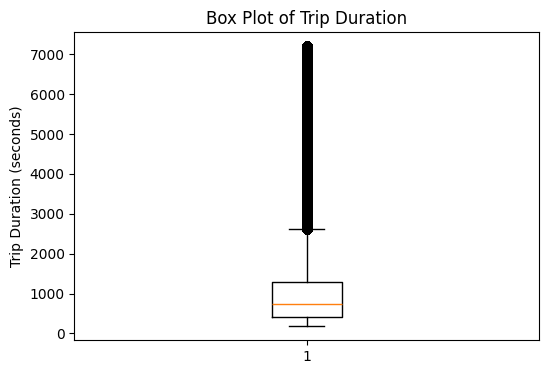

In [16]:
plt.figure(figsize=(6, 4))
plt.boxplot(df_par["trip_duration"].dropna())
plt.title("Box Plot of Trip Duration")
plt.ylabel("Trip Duration (seconds)")
plt.show()

## Part 3 Questions and Answers

### 1. Is the distribution of `trip_distance` symmetric or skewed? Justify by comparing mean and median.

The distribution of `trip_distance` is **right-skewed**, also called **positively skewed**.

The mean trip distance is **6.17 km**, while the median trip distance is **4.50 km**.

Since the **mean is greater than the median**, this shows that some very long trips are pulling the average upward. Most trips are probably shorter, but a smaller number of long-distance trips increase the mean.

Therefore, `trip_distance` is not symmetric. It is **right-skewed**.

---

### 2. Which measure of central tendency is most appropriate for `driver_rating`? Why?

The most appropriate measure of central tendency for `driver_rating` is the **median**.

Driver ratings are bounded between **1 and 5**, and they can be affected by a small number of unusually low ratings. The median is better because it is less affected by extreme values or outliers compared with the mean.

In this dataset, the `driver_rating` values range from **2.6 to 5.0**, so there are no invalid ratings. However, using the median still gives a better idea of the typical driver rating because ratings are ordinal-like and concentrated near the high end.

In [17]:
df_par.columns

Index(['trip_id', 'rider_id', 'driver_id', 'trip_start_time', 'trip_end_time',
       'trip_distance', 'trip_duration', 'fare_amount', 'surge_multiplier',
       'driver_rating', 'rider_rating', 'payment_method', 'traffic_condition',
       'weather', 'day_of_week', 'hour_of_day', 'driver_tenure_days',
       'rider_tenure_days'],
      dtype='str')

In [19]:
df_par["weather"].value_counts(normalize=True)

weather
Clear    0.599746
Rain     0.250125
Fog      0.100223
Storm    0.049906
Name: proportion, dtype: float64

In [20]:
df_par["traffic_condition"].value_counts(normalize=True)

traffic_condition
Moderate    0.424885
Light       0.399980
Heavy       0.175134
Name: proportion, dtype: float64

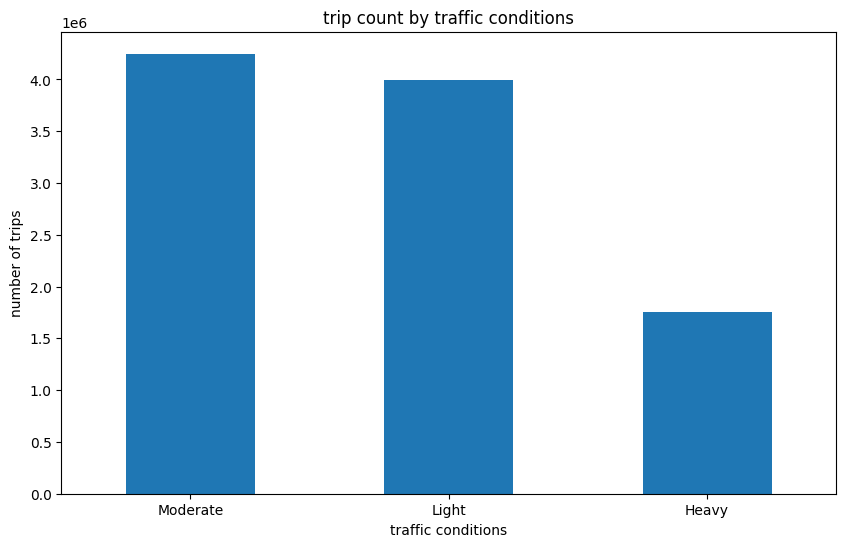

In [21]:
plt.figure(figsize=(10,6))
df_par["traffic_condition"].value_counts().plot(kind="bar")
plt.title("trip count by traffic conditions")
plt.xlabel("traffic conditions")
plt.ylabel("number of trips")
plt.xticks(rotation=0)
plt.show()

## 1. Most common and least common weather condition

Clear = 0.599746
Rain  = 0.250125
Fog   = 0.100223
Storm = 0.049906

The most common weather condition is Clear, with about 59.97% of trips.
The least common weather condition is Storm, with about 4.99% of trips.

## 3. Percentage of trips during Heavy traffic

Heavy = 0.175134
Percentage of trips during Heavy traffic = 0.175134 × 100 = 17.51%

1. The most common weather condition is **Clear**, accounting for approximately **59.97%** of all trips.  
   The least common weather condition is **Storm**, accounting for approximately **4.99%** of all trips.

3. Approximately **17.51%** of trips occurred during **Heavy traffic**.

In [22]:
avg_driver_rating_weather = (
    df_par[df_par["weather"].isin(["Storm", "Clear"])]
    .groupby("weather")["driver_rating"]
    .mean()
)
avg_driver_rating_weather

weather
Clear    4.435997
Storm    4.236086
Name: driver_rating, dtype: float64

In [26]:
avg_fare_payment = (
    df_par[df_par["payment_method"].isin(["Cash", "Card"])].groupby("payment_method")["fare_amount"].mean()
)
avg_fare_payment

payment_method
Card    13.139966
Cash    13.155739
Name: fare_amount, dtype: float64

In [39]:
df_par['surge_multiplier']> 1.5, df_par["trip_distance"]

(0           True
 1           True
 2          False
 3           True
 4           True
            ...  
 9999995     True
 9999996    False
 9999997     True
 9999998    False
 9999999    False
 Name: surge_multiplier, Length: 10000000, dtype: bool,
 0          1.7
 1          0.6
 2          4.8
 3          3.1
 4          7.0
           ... 
 9999995    7.8
 9999996    5.2
 9999997    5.2
 9999998    3.2
 9999999    1.4
 Name: trip_distance, Length: 10000000, dtype: float64)

In [45]:
avg_distance_surge = df_par[df_par['surge_multiplier'] > 1.5]['trip_distance'].mean()
avg_distance_surge

6.168912203129679

In [40]:
df_par['trip_distance'].mean()

6.170386839999995

In [51]:
df_par["day_of_week"].unique()

array([5, 3, 0, 4, 6, 2, 1], dtype=int64)

In [54]:
df_par['trip_day_type'] = df_par['day_of_week'].apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)
df_par["trip_day_type"].unique()

<ArrowStringArray>
['Weekend', 'Weekday']
Length: 2, dtype: str

In [57]:
df_par["trip_day_type"].sample(10)

4933701    Weekend
2696496    Weekend
4628661    Weekend
5337704    Weekday
8153813    Weekday
8742960    Weekday
883763     Weekend
1518657    Weekday
2342896    Weekend
9766620    Weekday
Name: trip_day_type, dtype: str

In [58]:
std_duration_day_type = df_par.groupby('trip_day_type')['trip_duration'].std()
std_duration_day_type

trip_day_type
Weekday    1000.628972
Weekend    1000.565797
Name: trip_duration, dtype: float64

In [59]:
fare_skew_high_rating = df_par[df_par['driver_rating'] >= 4.5]['fare_amount'].skew()
fare_skew_high_rating

3.8378563145858298

In [60]:
mean_distance_traffic = (
    df_par[df_par['traffic_condition'].isin(['Heavy', 'Light'])]
    .groupby('traffic_condition')['trip_distance']
    .mean()
)
mean_distance_traffic

traffic_condition
Heavy    6.175658
Light    6.163889
Name: trip_distance, dtype: float64

In [61]:
heavy_mean = mean_distance_traffic['Heavy']
light_mean = mean_distance_traffic['Light']
mean_difference = heavy_mean - light_mean
mean_difference

0.011768237690268357

In [70]:
df_par['duration_min'] = df_par['trip_duration'] / 60
df_par['is_weekend'] = (df_par['day_of_week'] >= 5).astype(int)
df_par[["duration_min","is_weekend"]].sample(10)

,duration_min,is_weekend
3527593,13.220000,0
127394,11.680000,1
260421,18.040000,0
5471225,3.850000,1
388539,38.033333,0
3576906,10.116667,0
7158124,29.733333,1
7616735,20.316667,0
4464856,8.733333,0
7482076,11.340000,0


In [68]:
df_par['driver_exp'] = pd.cut(
    df_par['driver_tenure_days'],
    bins=[0, 30, 90, 180, 10000],
    labels=[
        'New (<30d)',
        'Moderate (30-90d)',
        'Experienced (90-180d)',
        'Veteran (>180d)'
    ],
    include_lowest=True
)
df_par[['trip_duration', 'duration_min', 'day_of_week', 'is_weekend', 
        'driver_tenure_days', 'driver_exp']].sample(10)

,trip_duration,duration_min,day_of_week,is_weekend,driver_tenure_days,driver_exp
8487154,530.4,8.840000,1,0,171,Experienced (90-180d)
8993081,247.0,4.116667,5,1,16,New (<30d)
5463970,727.0,12.116667,0,0,63,Moderate (30-90d)
4369885,1964.0,32.733333,6,1,162,Experienced (90-180d)
1525499,180.0,3.000000,5,1,69,Moderate (30-90d)
9193467,231.6,3.860000,4,0,78,Moderate (30-90d)
3370789,981.0,16.350000,2,0,220,Veteran (>180d)
7544200,180.0,3.000000,6,1,83,Moderate (30-90d)
660517,374.0,6.233333,5,1,221,Veteran (>180d)
2036905,318.0,5.300000,3,0,3,New (<30d)


In [71]:
avg_duration_new_driver = df_par[df_par['driver_exp'] == 'New (<30d)']['duration_min'].mean()
avg_duration_new_driver

17.466052564751507

In [72]:
weekend_high_surge_count = df_par[
    (df_par['is_weekend'] == 1) & 
    (df_par['surge_multiplier'] > 2.0)
].shape[0]
weekend_high_surge_count

729263

In [73]:
df_sample = df_par.sample(n=100000, random_state=42)

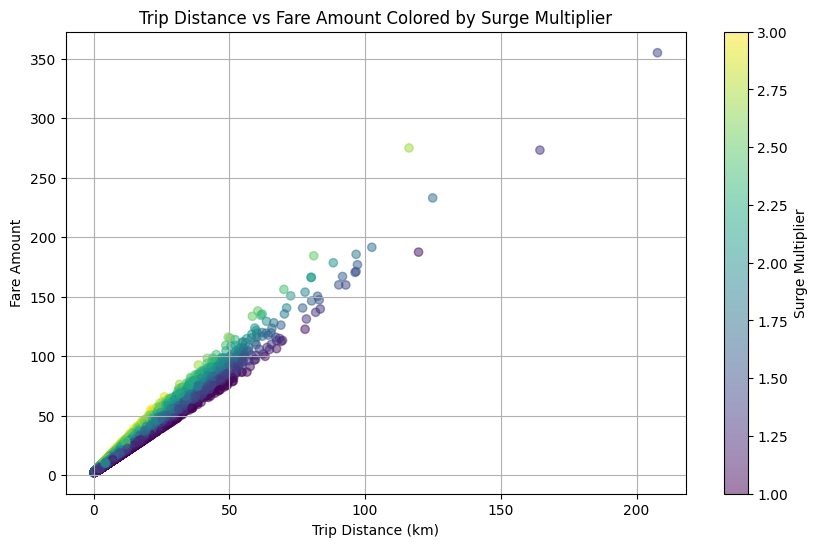

In [74]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df_sample['trip_distance'],
    df_sample['fare_amount'],
    c=df_sample['surge_multiplier'],
    cmap='viridis',
    alpha=0.5
)

plt.colorbar(scatter, label='Surge Multiplier')
plt.title('Trip Distance vs Fare Amount Colored by Surge Multiplier')
plt.xlabel('Trip Distance (km)')
plt.ylabel('Fare Amount')
plt.grid(True)
plt.show()

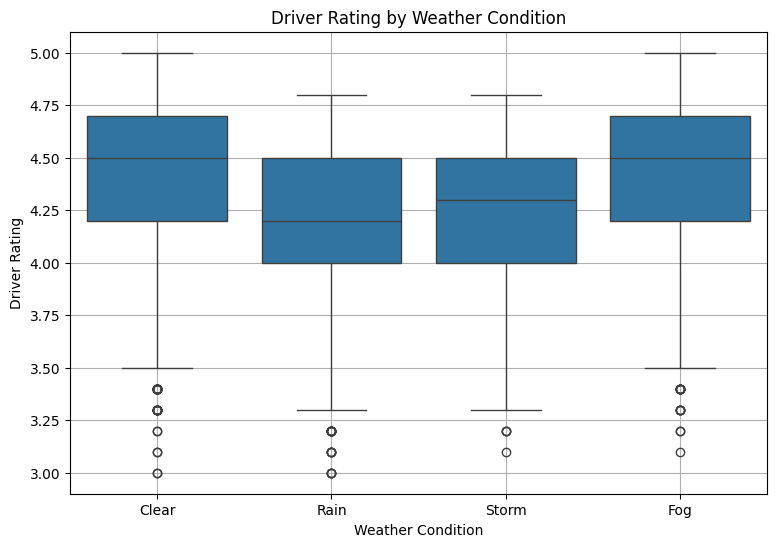

In [75]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_sample,
    x='weather',
    y='driver_rating'
)

plt.title('Driver Rating by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Driver Rating')
plt.grid(True)
plt.show()

In [76]:
weather_median = df_par.groupby('weather')['driver_rating'].median()
weather_median

weather
Clear    4.5
Fog      4.5
Rain     4.3
Storm    4.3
Name: driver_rating, dtype: float64

In [79]:
weather_iqr = df_par.groupby('weather')['driver_rating'].quantile(0.75) - df_par.groupby('weather')['driver_rating'].quantile(0.25)
weather_iqr

weather
Clear    0.5
Fog      0.5
Rain     0.5
Storm    0.5
Name: driver_rating, dtype: float64

In [78]:
weather_median.idxmin(), weather_iqr.idxmax()

('Rain', 'Clear')

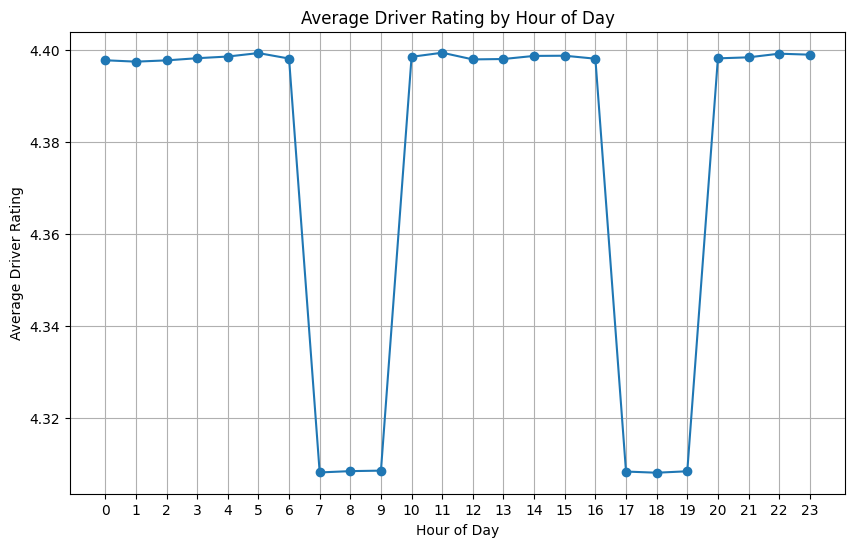

In [80]:
avg_rating_hour = df_par.groupby('hour_of_day')['driver_rating'].mean()

plt.figure(figsize=(10, 6))

plt.plot(
    avg_rating_hour.index,
    avg_rating_hour.values,
    marker='o'
)

plt.title('Average Driver Rating by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Driver Rating')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

In [81]:
lowest_rating = avg_rating_hour.min()
lowest_hours = avg_rating_hour[avg_rating_hour == lowest_rating]

lowest_rating, lowest_hours

(4.308127819494775,
 hour_of_day
 18    4.308128
 Name: driver_rating, dtype: float64)

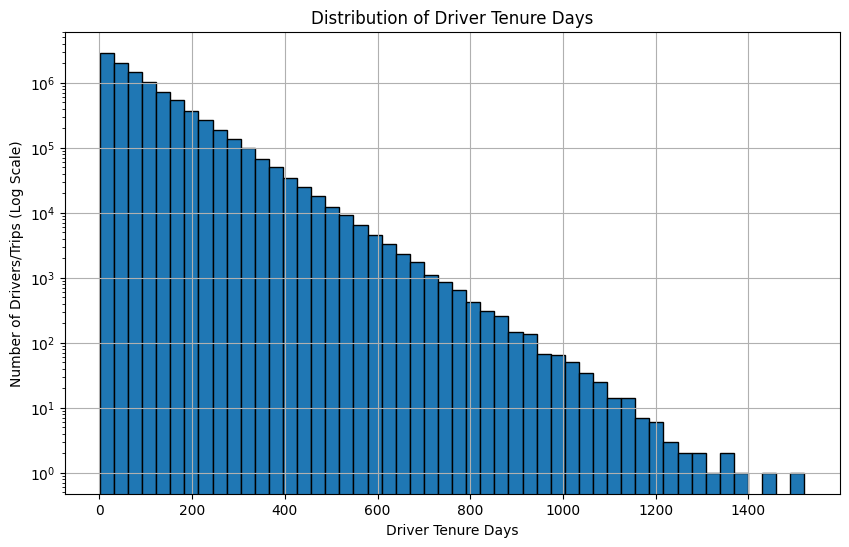

In [82]:
plt.figure(figsize=(10, 6))

plt.hist(
    df_par['driver_tenure_days'],
    bins=50,
    edgecolor='black'
)

plt.yscale('log')
plt.title('Distribution of Driver Tenure Days')
plt.xlabel('Driver Tenure Days')
plt.ylabel('Number of Drivers/Trips (Log Scale)')
plt.grid(True)
plt.show()

### Part 8: Extract Actionable Insights

**Insight 1:** Most ride-hailing demand occurs during clear weather.  
**Evidence:** Clear weather accounts for **59.97%** of all trips, which is much higher than Rain (**25.01%**), Fog (**10.02%**), and Storm (**4.99%**).  
**Recommendation:** The company should keep normal driver supply high during clear weather because this is when most trips happen.

**Insight 2:** Storm trips are rare but operationally important.  
**Evidence:** Storm weather represents only **4.99%** of trips, but storm conditions can create safety risks and service delays.  
**Recommendation:** The company should provide storm-driving safety guidelines and special incentives for drivers who work during storm conditions.

**Insight 3:** Heavy traffic affects a significant number of trips.  
**Evidence:** Heavy traffic occurs in **17.51%** of trips, while Moderate traffic occurs in **42.49%** and Light traffic occurs in **40.00%**.  
**Recommendation:** The company should use traffic-aware route optimization and place more drivers near high-demand areas during heavy traffic periods.

**Insight 4:** Trip distance is right-skewed.  
**Evidence:** The average trip distance is **6.17 km**, but the median trip distance is **4.50 km**. Since the mean is higher than the median, a smaller number of long trips are increasing the average.  
**Recommendation:** The company should analyze short and long trips separately because average distance alone does not represent most rides accurately.

**Insight 5:** Fare amount has high variation.  
**Evidence:** The average fare is **13.15**, but the standard deviation is **10.67**, and the maximum fare reaches **523.15**.  
**Recommendation:** Very high fare values should be monitored because they may indicate very long trips, high surge pricing, or possible outliers.

**Insight 6:** Driver ratings are higher in clear and foggy weather than in rain and storm.  
**Evidence:** Average driver rating in Clear weather is **4.436**, Fog is **4.436**, Rain is **4.236**, and Storm is **4.236**.  
**Recommendation:** The company should support drivers more during rain and storm conditions because bad weather may reduce rider satisfaction.

**Insight 7:** Payment method does not strongly affect fare amount.  
**Evidence:** Average fare for Card trips is **13.140**, Cash trips is **13.156**, and Wallet trips is **13.155**. The differences are very small.  
**Recommendation:** The company does not need different pricing strategies for different payment methods, but it can still promote digital payments for convenience and safety.

**Insight 8:** High surge trips have almost the same average distance as overall trips.  
**Evidence:** The average trip distance for trips with surge multiplier greater than **1.5** is **6.17 km**, almost equal to the overall average trip distance of **6.17 km**.  
**Recommendation:** Surge pricing is likely influenced more by demand, supply, traffic, or timing than by trip distance alone. The company should investigate peak hours and driver availability.

**Insight 9:** Weekend high-surge demand is very large.  
**Evidence:** There are **729,263** weekend trips where the surge multiplier is greater than **2.0**.  
**Recommendation:** The company should encourage more drivers to work on weekends through bonuses or targeted incentives to reduce extreme surge pricing.

**Insight 10:** Driver experience has only a small effect on average trip duration.  
**Evidence:** New drivers average **17.47 minutes**, Moderate drivers **17.44 minutes**, Experienced drivers **17.45 minutes**, and Veteran drivers **17.42 minutes**. The difference is very small.  
**Recommendation:** Since trip duration is similar across experience levels, the company should focus more on route conditions, traffic, and demand patterns rather than driver tenure alone.

In [86]:
df_model = df_par.drop(
    ['trip_id', 'rider_id', 'driver_id', 'trip_start_time', 'trip_end_time'],
    axis=1
)

In [87]:
df_par.shape, df_model.shape

((10000000, 22), (10000000, 17))

In [88]:
print(df_model.columns)

Index(['trip_distance', 'trip_duration', 'fare_amount', 'surge_multiplier',
       'driver_rating', 'rider_rating', 'payment_method', 'traffic_condition',
       'weather', 'day_of_week', 'hour_of_day', 'driver_tenure_days',
       'rider_tenure_days', 'trip_day_type', 'duration_min', 'is_weekend',
       'driver_exp'],
      dtype='str')


In [89]:
df_model.to_parquet(
    'swiftride_cleaned.parquet',
    engine='fastparquet',
    index=False
)

In [90]:
df_clean = pd.read_parquet('swiftride_cleaned.parquet',
    engine='fastparquet',)
df_clean

,trip_distance,trip_duration,fare_amount,surge_multiplier,driver_rating,rider_rating,payment_method,traffic_condition,weather,day_of_week,hour_of_day,driver_tenure_days,rider_tenure_days,trip_day_type,duration_min,is_weekend,driver_exp
0,1.7,239.4,5.40,2.0,4.2,4.8,Wallet,Heavy,Clear,5,7,37,19,Weekend,3.990000,1,Moderate (30-90d)
1,0.6,180.0,3.20,2.0,4.1,4.6,Cash,Heavy,Rain,3,6,87,58,Weekday,3.000000,0,Moderate (30-90d)
2,4.8,610.0,9.20,1.0,4.5,4.6,Wallet,Moderate,Clear,0,4,24,34,Weekday,10.166667,0,New (<30d)
3,3.1,342.0,7.58,1.6,4.4,4.9,Card,Light,Clear,4,0,3,222,Weekday,5.700000,0,New (<30d)
4,7.0,1002.0,15.30,1.8,4.4,4.5,Cash,Moderate,Clear,0,2,70,107,Weekday,16.700000,0,Moderate (30-90d)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9999995,7.8,1359.6,17.21,1.9,4.3,4.8,Card,Light,Rain,3,12,153,156,Weekday,22.660000,0,Experienced (90-180d)
9999996,5.2,604.0,11.10,1.5,4.7,4.3,Card,Moderate,Clear,5,20,123,7,Weekend,10.066667,1,Experienced (90-180d)
9999997,5.2,1044.0,11.62,1.7,4.2,4.8,Card,Moderate,Rain,3,8,54,90,Weekday,17.400000,0,Moderate (30-90d)
9999998,3.2,848.0,6.80,1.0,4.6,4.8,Card,Light,Clear,4,17,101,155,Weekday,14.133333,0,Experienced (90-180d)


### The main difference noticed is that Parquet is faster and more suitable for big data compared to CSV. CSV is simple and human-readable, but it becomes slow and large when working with millions of rows. Since this dataset contains 10 million records, Parquet is the better choice.